In [17]:
import torch
import transformers

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)

PyTorch version: 2.13.0+cpu
Transformers version: 5.15.1


In [7]:
import torch
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [9]:
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"

print("Selected Language Model:", MODEL_NAME)
print("Task: Sentiment Analysis")
print("Architecture: DistilBERT")
print("Base architecture: BERT")

Selected Language Model: distilbert-base-uncased-finetuned-sst-2-english
Task: Sentiment Analysis
Architecture: DistilBERT
Base architecture: BERT


In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully.")
print("Vocabulary size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

C:\Users\prith\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\prith\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Tokenizer loaded successfully.
Vocabulary size: 30522


In [13]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

print("Model loaded successfully.")
print("Number of output classes:", model.config.num_labels)
print("Labels:", model.config.id2label)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded successfully.
Number of output classes: 2
Labels: {0: 'NEGATIVE', 1: 'POSITIVE'}


In [14]:
print("Model Configuration")
print("-" * 40)

print("Model type:", model.config.model_type)
print("Hidden size:", model.config.hidden_size)
print("Number of hidden layers:", model.config.num_hidden_layers)
print("Number of attention heads:", model.config.num_attention_heads)
print("Maximum position embeddings:", model.config.max_position_embeddings)
print("Number of labels:", model.config.num_labels)

Model Configuration
----------------------------------------
Model type: distilbert
Hidden size: 768
Number of hidden layers: 6
Number of attention heads: 12
Maximum position embeddings: 512
Number of labels: 2


In [19]:
total_parameters = sum(p.numel() for p in model.parameters())
trainable_parameters = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print("Total Parameters:", f"{total_parameters:,}")
print("Trainable Parameters:", f"{trainable_parameters:,}")

Total Parameters: 66,955,010
Trainable Parameters: 66,955,010


In [21]:
classifier = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer
)

print("Sentiment analysis pipeline created successfully.")

Sentiment analysis pipeline created successfully.


In [23]:
texts = [
    "I really enjoyed this movie. It was fantastic!",
    "The product quality is excellent and I am very happy.",
    "This is the worst experience I have ever had.",
    "I am extremely disappointed with the service.",
    "The movie was okay, but nothing special."
]

results = classifier(texts)

for text, result in zip(texts, results):
    print("Text:", text)
    print("Prediction:", result["label"])
    print("Confidence:", round(result["score"], 4))
    print("-" * 60)

Text: I really enjoyed this movie. It was fantastic!
Prediction: POSITIVE
Confidence: 0.9999
------------------------------------------------------------
Text: The product quality is excellent and I am very happy.
Prediction: POSITIVE
Confidence: 0.9999
------------------------------------------------------------
Text: This is the worst experience I have ever had.
Prediction: NEGATIVE
Confidence: 0.9998
------------------------------------------------------------
Text: I am extremely disappointed with the service.
Prediction: NEGATIVE
Confidence: 0.9998
------------------------------------------------------------
Text: The movie was okay, but nothing special.
Prediction: NEGATIVE
Confidence: 0.9935
------------------------------------------------------------


In [25]:
sample_text = "Artificial intelligence is transforming cybersecurity."

tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.encode(sample_text)

print("Original Text:")
print(sample_text)

print("\nTokens:")
print(tokens)

print("\nToken IDs:")
print(token_ids)

Original Text:
Artificial intelligence is transforming cybersecurity.

Tokens:
['artificial', 'intelligence', 'is', 'transforming', 'cyber', '##se', '##cu', '##rity', '.']

Token IDs:
[101, 7976, 4454, 2003, 17903, 16941, 3366, 10841, 15780, 1012, 102]


In [27]:
user_text = input("Enter a sentence for sentiment analysis: ")

result = classifier(user_text)[0]

print("\nPrediction Result")
print("-" * 30)
print("Text:", user_text)
print("Sentiment:", result["label"])
print("Confidence:", round(result["score"], 4))

Enter a sentence for sentiment analysis:  Artificial Intelligence is taking over jobs



Prediction Result
------------------------------
Text: Artificial Intelligence is taking over jobs
Sentiment: NEGATIVE
Confidence: 0.9905


In [41]:
data = {
    "text": [
        "I absolutely love this product.",
        "The service was excellent.",
        "This movie was amazing.",
        "I am very happy with my purchase.",
        "The experience was wonderful.",
        "The product works perfectly.",
        "I hate this product.",
        "The service was terrible.",
        "This movie was extremely boring.",
        "I am disappointed with my purchase.",
        "The experience was horrible.",
        "The product stopped working immediately.",
        "The quality is fantastic."
        
    ],

    "actual": [
        "POSITIVE",
        "POSITIVE",
        "POSITIVE",
        "POSITIVE",
        "POSITIVE",
        "POSITIVE",
        "NEGATIVE",
        "NEGATIVE",
        "NEGATIVE",
        "NEGATIVE",
        "NEGATIVE",
        "NEGATIVE",
        "POSITIVE."
    ]
}

df = pd.DataFrame(data)

df.head()

,text,actual
0,I absolutely love this product.,POSITIVE
1,The service was excellent.,POSITIVE
2,This movie was amazing.,POSITIVE
3,I am very happy with my purchase.,POSITIVE
4,The experience was wonderful.,POSITIVE


In [43]:
predictions = classifier(df["text"].tolist())

df["predicted"] = [result["label"] for result in predictions]
df["confidence"] = [result["score"] for result in predictions]

df

,text,actual,predicted,confidence
0,I absolutely love this product.,POSITIVE,POSITIVE,0.999881
1,The service was excellent.,POSITIVE,POSITIVE,0.999851
2,This movie was amazing.,POSITIVE,POSITIVE,0.999882
3,I am very happy with my purchase.,POSITIVE,POSITIVE,0.999869
4,The experience was wonderful.,POSITIVE,POSITIVE,0.999888
5,The product works perfectly.,POSITIVE,POSITIVE,0.999874
6,I hate this product.,NEGATIVE,NEGATIVE,0.999760
7,The service was terrible.,NEGATIVE,NEGATIVE,0.999651
8,This movie was extremely boring.,NEGATIVE,NEGATIVE,0.999772
9,I am disappointed with my purchase.,NEGATIVE,NEGATIVE,0.999789


In [45]:
accuracy = accuracy_score(
    df["actual"],
    df["predicted"]
)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 92.31 %


In [49]:
print("Actual labels:")
print(df["actual"].unique())

print("\nPredicted labels:")
print(df["predicted"].unique())

Actual labels:
['POSITIVE' 'NEGATIVE' 'POSITIVE.']

Predicted labels:
['POSITIVE' 'NEGATIVE']


In [51]:
# Clean the actual and predicted labels

df["actual"] = (
    df["actual"]
    .str.upper()
    .str.strip()
    .str.replace(".", "", regex=False)
)

df["predicted"] = (
    df["predicted"]
    .str.upper()
    .str.strip()
    .str.replace(".", "", regex=False)
)

print("Actual labels after cleaning:")
print(df["actual"].unique())

print("\nPredicted labels after cleaning:")
print(df["predicted"].unique())

Actual labels after cleaning:
['POSITIVE' 'NEGATIVE']

Predicted labels after cleaning:
['POSITIVE' 'NEGATIVE']


In [53]:
precision = precision_score(
    df["actual"],
    df["predicted"],
    pos_label="POSITIVE"
)

recall = recall_score(
    df["actual"],
    df["predicted"],
    pos_label="POSITIVE"
)

f1 = f1_score(
    df["actual"],
    df["predicted"],
    pos_label="POSITIVE"
)

print("Performance Metrics")
print("-" * 40)
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Performance Metrics
----------------------------------------
Accuracy : 0.9231
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [55]:
print(
    classification_report(
        df["actual"],
        df["predicted"]
    )
)

              precision    recall  f1-score   support

    NEGATIVE       1.00      1.00      1.00         6
    POSITIVE       1.00      1.00      1.00         7

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



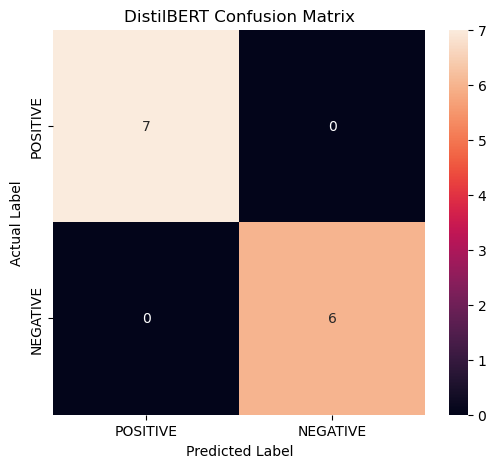

In [57]:
cm = confusion_matrix(
    df["actual"],
    df["predicted"],
    labels=["POSITIVE", "NEGATIVE"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["POSITIVE", "NEGATIVE"],
    yticklabels=["POSITIVE", "NEGATIVE"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("DistilBERT Confusion Matrix")
plt.show()

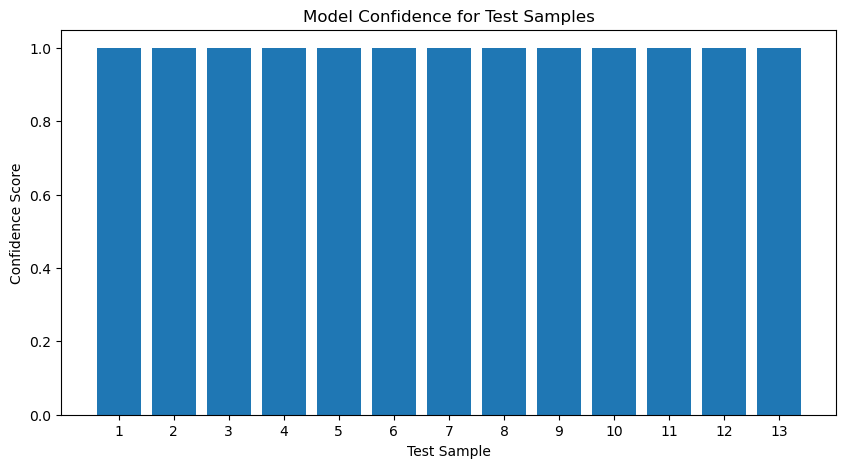

In [59]:
plt.figure(figsize=(10, 5))

plt.bar(
    range(len(df)),
    df["confidence"]
)

plt.xlabel("Test Sample")
plt.ylabel("Confidence Score")
plt.title("Model Confidence for Test Samples")
plt.xticks(range(len(df)), range(1, len(df) + 1))

plt.show()

In [61]:
test_text = "Artificial intelligence is very useful."

start_time = time.time()

result = classifier(test_text)

end_time = time.time()

inference_time = end_time - start_time

print("Input:", test_text)
print("Prediction:", result[0]["label"])
print("Confidence:", round(result[0]["score"], 4))
print("Inference Time:", round(inference_time, 4), "seconds")

Input: Artificial intelligence is very useful.
Prediction: POSITIVE
Confidence: 0.9993
Inference Time: 0.0614 seconds


In [63]:
comparison_texts = [
    "I love this application.",
    "This application is terrible.",
    "The service is excellent.",
    "The service is very disappointing.",
    "The product is better than I expected.",
    "I regret buying this product."
]

comparison_results = classifier(comparison_texts)

comparison_df = pd.DataFrame({
    "Text": comparison_texts,
    "Prediction": [r["label"] for r in comparison_results],
    "Confidence": [round(r["score"], 4) for r in comparison_results]
})

comparison_df

,Text,Prediction,Confidence
0,I love this application.,POSITIVE,0.9999
1,This application is terrible.,NEGATIVE,0.9998
2,The service is excellent.,POSITIVE,0.9999
3,The service is very disappointing.,NEGATIVE,0.9998
4,The product is better than I expected.,POSITIVE,0.9997
5,I regret buying this product.,NEGATIVE,0.9983


In [65]:
incorrect = df[df["actual"] != df["predicted"]]

print("Number of incorrect predictions:", len(incorrect))

incorrect

Number of incorrect predictions: 0


,text,actual,predicted,confidence


In [67]:
correct = df[df["actual"] == df["predicted"]]

print("Number of correct predictions:", len(correct))

correct

Number of correct predictions: 13


,text,actual,predicted,confidence
0,I absolutely love this product.,POSITIVE,POSITIVE,0.999881
1,The service was excellent.,POSITIVE,POSITIVE,0.999851
2,This movie was amazing.,POSITIVE,POSITIVE,0.999882
3,I am very happy with my purchase.,POSITIVE,POSITIVE,0.999869
4,The experience was wonderful.,POSITIVE,POSITIVE,0.999888
5,The product works perfectly.,POSITIVE,POSITIVE,0.999874
6,I hate this product.,NEGATIVE,NEGATIVE,0.999760
7,The service was terrible.,NEGATIVE,NEGATIVE,0.999651
8,This movie was extremely boring.,NEGATIVE,NEGATIVE,0.999772
9,I am disappointed with my purchase.,NEGATIVE,NEGATIVE,0.999789


In [69]:
average_confidence = df["confidence"].mean()

print(
    "Average Model Confidence:",
    round(average_confidence * 100, 2),
    "%"
)

Average Model Confidence: 99.98 %


In [71]:
advanced_examples = [
    "I thought the movie would be bad, but it was actually fantastic.",
    "The product is not good.",
    "I am not unhappy with the service.",
    "The movie was surprisingly good.",
    "Although the product is expensive, its quality is excellent.",
    "The service was not what I expected."
]

advanced_results = classifier(advanced_examples)

for text, result in zip(advanced_examples, advanced_results):
    print("Text:", text)
    print("Prediction:", result["label"])
    print("Confidence:", round(result["score"], 4))
    print("-" * 70)

Text: I thought the movie would be bad, but it was actually fantastic.
Prediction: POSITIVE
Confidence: 0.9998
----------------------------------------------------------------------
Text: The product is not good.
Prediction: NEGATIVE
Confidence: 0.9998
----------------------------------------------------------------------
Text: I am not unhappy with the service.
Prediction: POSITIVE
Confidence: 0.9946
----------------------------------------------------------------------
Text: The movie was surprisingly good.
Prediction: POSITIVE
Confidence: 0.9999
----------------------------------------------------------------------
Text: Although the product is expensive, its quality is excellent.
Prediction: POSITIVE
Confidence: 0.9999
----------------------------------------------------------------------
Text: The service was not what I expected.
Prediction: NEGATIVE
Confidence: 0.9997
----------------------------------------------------------------------


In [73]:
summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Average Confidence"
    ],
    "Score": [
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(average_confidence, 4)
    ]
})

summary

,Metric,Score
0,Accuracy,0.9231
1,Precision,1.0000
2,Recall,1.0000
3,F1 Score,1.0000
4,Average Confidence,0.9998
